## Langkah 1: Setup dan Verifikasi Lingkungan

In [2]:
import sys
print(sys.executable)

/home/fatima/miniconda3/envs/parallel/bin/python3.11


In [3]:
import subprocess, os, platform
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Verifikasi GCC dan OpenMP
result = subprocess.run(['gcc', '--version'], capture_output=True, text=True)
print('=== GCC Version ===')
print(result.stdout.split('\n')[0])

result2 = subprocess.run(
    'echo | cpp -fopenmp -dM | grep -i openmp',
    shell=True,
    capture_output=True,
    text=True
)

print('\n=== OpenMP Support ===')
print(result2.stdout if result2.stdout else 'OpenMP tidak terdeteksi!')
print(f'\nJumlah CPU cores: {os.cpu_count()}')
print(f'Sistem Operasi   : {platform.system()} {platform.release()}')

=== GCC Version ===
gcc (Ubuntu 11.4.0-1ubuntu1~22.04.3) 11.4.0

=== OpenMP Support ===
#define _OPENMP 201511


Jumlah CPU cores: 8
Sistem Operasi   : Linux 6.6.114.1-microsoft-standard-WSL2


In [4]:
# Buat direktori kerja untuk file C
os.makedirs('openmp_files', exist_ok=True)
print('Direktori openmp_files siap.')

Direktori openmp_files siap.


## Langkah 2: Test Hello World OpenMP

In [5]:
%%writefile openmp_files/test_openmp.c
#include <stdio.h>
#include <omp.h>

int main() {
    printf("Total threads tersedia: %d\n", omp_get_max_threads());

    #pragma omp parallel
    {
        int id = omp_get_thread_num();
        printf("Hello dari thread %d\n", id);
    }

    return 0;
}

Overwriting openmp_files/test_openmp.c


In [6]:
# Kompilasi dan jalankan
!gcc -fopenmp openmp_files/test_openmp.c -o openmp_files/test_openmp
!./openmp_files/test_openmp

Total threads tersedia: 8
Hello dari thread 0
Hello dari thread 6
Hello dari thread 2
Hello dari thread 4
Hello dari thread 7
Hello dari thread 3
Hello dari thread 5
Hello dari thread 1


## Langkah 3: Perkalian Matriks Serial (Baseline)

In [7]:
%%writefile openmp_files/matrix_serial.c
#include <stdio.h>
#include <stdlib.h>
#include <time.h>

#define N 1024

void matrix_multiply_serial(double A[N][N], double B[N][N], double C[N][N]) {
    for (int i = 0; i < N; i++)
        for (int j = 0; j < N; j++) {
            C[i][j] = 0;
            for (int k = 0; k < N; k++)
                C[i][j] += A[i][k] * B[k][j];
        }
}

int main() {
    static double A[N][N], B[N][N], C[N][N];

    srand(42);

    for (int i = 0; i < N; i++)
        for (int j = 0; j < N; j++) {
            A[i][j] = (double)rand() / RAND_MAX;
            B[i][j] = (double)rand() / RAND_MAX;
        }

    struct timespec start, end;

    clock_gettime(CLOCK_MONOTONIC, &start);

    matrix_multiply_serial(A, B, C);

    clock_gettime(CLOCK_MONOTONIC, &end);

    double elapsed = (end.tv_sec - start.tv_sec) +
                     (end.tv_nsec - start.tv_nsec) / 1e9;

    double gflops = (2.0 * N * N * N) / (elapsed * 1e9);

    printf("SERIAL_TIME=%.4f\n", elapsed);
    printf("SERIAL_GFLOPS=%.4f\n", gflops);

    return 0;
}

Overwriting openmp_files/matrix_serial.c


In [8]:
# Kompilasi
!gcc -O2 openmp_files/matrix_serial.c -o openmp_files/matrix_serial

# Jalankan dan simpan hasilnya ke variabel Python
result = subprocess.run(
    './openmp_files/matrix_serial',
    capture_output=True,
    text=True
)

output = result.stdout
print(output)

# Parse hasil
serial_time = float(
    [l.split('=')[1]
     for l in output.split('\n')
     if 'SERIAL_TIME' in l][0]
)

serial_gflops = float(
    [l.split('=')[1]
     for l in output.split('\n')
     if 'SERIAL_GFLOPS' in l][0]
)

print(f'Waktu Serial  : {serial_time:.4f} detik')
print(f'Serial GFLOPS : {serial_gflops:.4f}')

SERIAL_TIME=10.7474
SERIAL_GFLOPS=0.1998

Waktu Serial  : 10.7474 detik
Serial GFLOPS : 0.1998


## Langkah 4: Perkalian Matriks Paralel + Speedup Analysis

In [9]:
%%writefile openmp_files/matrix_parallel.c
#include <stdio.h>
#include <stdlib.h>
#include <omp.h>
#include <time.h>

#define N 1024

int main(int argc, char* argv[]) {
    int num_threads = (argc > 1) ? atoi(argv[1]) : 4;
    omp_set_num_threads(num_threads);

    static double A[N][N], B[N][N], C[N][N];

    srand(42);

    for (int i = 0; i < N; i++)
        for (int j = 0; j < N; j++) {
            A[i][j] = (double)rand() / RAND_MAX;
            B[i][j] = (double)rand() / RAND_MAX;
        }

    double start = omp_get_wtime();

    #pragma omp parallel for
    for (int i = 0; i < N; i++)
        for (int j = 0; j < N; j++) {
            C[i][j] = 0;
            for (int k = 0; k < N; k++)
                C[i][j] += A[i][k] * B[k][j];
        }

    double end = omp_get_wtime();

    printf("THREADS=%d TIME=%.4f\n", num_threads, end - start);

    return 0;
}

Overwriting openmp_files/matrix_parallel.c


In [10]:
!gcc -fopenmp -O2 openmp_files/matrix_parallel.c -o openmp_files/matrix_parallel

# Eksperimen dengan berbagai jumlah thread
thread_counts = [1, 2, 4, 8, 16]
parallel_times = []

for t in thread_counts:
    res = subprocess.run(f'./openmp_files/matrix_parallel {t}',
                         shell=True, capture_output=True, text=True)
    line = res.stdout.strip()
    time_val = float(line.split('TIME=')[1])
    parallel_times.append(time_val)
    print(f'Threads={t:2d}: {time_val:.4f} detik')

# Hitung Speedup dan Efficiency
speedups    = [serial_time / t for t in parallel_times]
efficiencies = [(s / th) * 100 for s, th in zip(speedups, thread_counts)]

df_speedup = pd.DataFrame({
    'Jumlah Thread': thread_counts,
    'Waktu (detik)': [f'{t:.4f}' for t in parallel_times],
    'Speedup'       : [f'{s:.3f}' for s in speedups],
    'Efficiency (%)':[f'{e:.1f}' for e in efficiencies]
})
print('\n--- Tabel Speedup Analysis ---')
print(df_speedup.to_string(index=False))


Threads= 1: 8.3849 detik
Threads= 2: 3.7985 detik
Threads= 4: 2.1472 detik
Threads= 8: 1.4434 detik
Threads=16: 1.5025 detik

--- Tabel Speedup Analysis ---
 Jumlah Thread Waktu (detik) Speedup Efficiency (%)
             1        8.3849   1.282          128.2
             2        3.7985   2.829          141.5
             4        2.1472   5.005          125.1
             8        1.4434   7.446           93.1
            16        1.5025   7.153           44.7


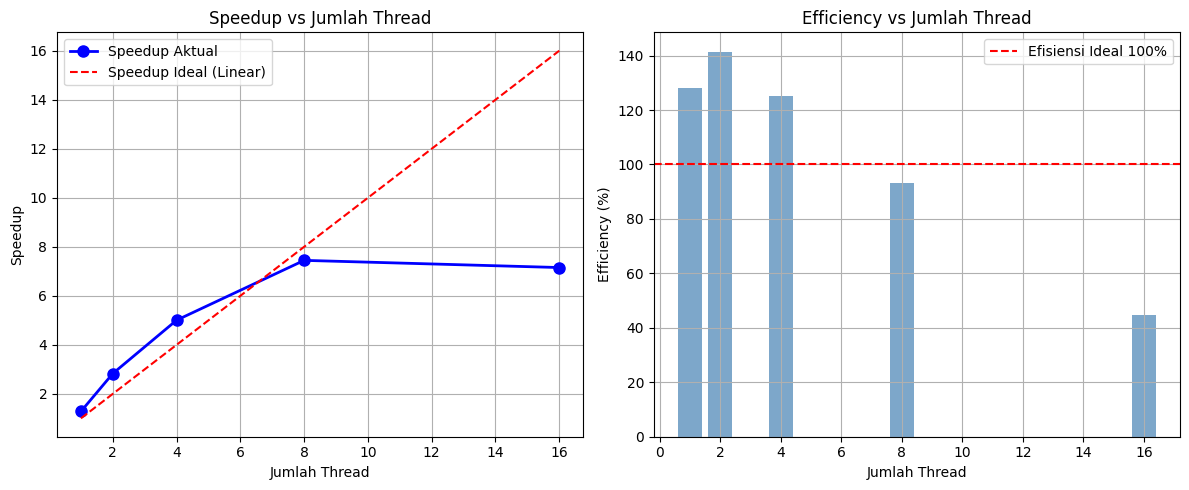

Grafik disimpan ke openmp_files/speedup_analysis.png


In [11]:
# Visualisasi Speedup
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(thread_counts, speedups, 'bo-', linewidth=2, markersize=8, label='Speedup Aktual')
axes[0].plot(thread_counts, thread_counts, 'r--', label='Speedup Ideal (Linear)')
axes[0].set_xlabel('Jumlah Thread'); axes[0].set_ylabel('Speedup')
axes[0].set_title('Speedup vs Jumlah Thread'); axes[0].legend(); axes[0].grid(True)

axes[1].bar(thread_counts, efficiencies, color='steelblue', alpha=0.7)
axes[1].axhline(y=100, color='r', linestyle='--', label='Efisiensi Ideal 100%')
axes[1].set_xlabel('Jumlah Thread'); axes[1].set_ylabel('Efficiency (%)')
axes[1].set_title('Efficiency vs Jumlah Thread'); axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.savefig('openmp_files/speedup_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafik disimpan ke openmp_files/speedup_analysis.png')


## Langkah 5: Eksperimen Scheduling Strategies

In [12]:
%%writefile openmp_files/matrix_schedule.c
#include <stdio.h>
#include <stdlib.h>
#include <omp.h>

#define N 1024
#define NUM_THREADS 4

int main(int argc, char* argv[]) {
    // argv[1]=schedule_type (static/dynamic/guided), argv[2]=chunk_size
    char *sched = (argc > 1) ? argv[1] : "static";
    int chunk   = (argc > 2) ? atoi(argv[2]) : 64;
    static double A[N][N], B[N][N], C[N][N];
    srand(42);
    for (int i = 0; i < N; i++)
        for (int j = 0; j < N; j++) {
            A[i][j] = (double)rand() / RAND_MAX;
            B[i][j] = (double)rand() / RAND_MAX;
        }
    omp_set_num_threads(NUM_THREADS);
    char env_str[64];
    snprintf(env_str, 64, "%s,%d", sched, chunk);
    setenv("OMP_SCHEDULE", env_str, 1);
    double start = omp_get_wtime();
    #pragma omp parallel for schedule(runtime)
    for (int i = 0; i < N; i++)
        for (int j = 0; j < N; j++) {
            C[i][j] = 0;
            for (int k = 0; k < N; k++)
                C[i][j] += A[i][k] * B[k][j];
        }
    double end = omp_get_wtime();
    printf("SCHED=%s CHUNK=%d TIME=%.4f\n", sched, chunk, end - start);
    return 0;
}


Overwriting openmp_files/matrix_schedule.c


In [13]:
!gcc -fopenmp -O2 openmp_files/matrix_schedule.c -o openmp_files/matrix_schedule

schedules   = ['static', 'dynamic', 'guided']
chunk_sizes = [16, 64, 256, 1024]
sched_results = {}

for sched in schedules:
    times = []
    for chunk in chunk_sizes:
        res = subprocess.run(f'./openmp_files/matrix_schedule {sched} {chunk}',
                             shell=True, capture_output=True, text=True)
        t = float(res.stdout.split('TIME=')[1].strip())
        times.append(t)
        print(f'{sched:8s} chunk={chunk:4d}: {t:.4f} detik')
    sched_results[sched] = times

print('\nEksperimen Scheduling selesai!')


static   chunk=  16: 3.2343 detik
static   chunk=  64: 2.9965 detik
static   chunk= 256: 2.6997 detik
static   chunk=1024: 2.0852 detik
dynamic  chunk=  16: 2.6525 detik
dynamic  chunk=  64: 2.4373 detik
dynamic  chunk= 256: 2.6185 detik
dynamic  chunk=1024: 2.5337 detik
guided   chunk=  16: 2.5034 detik
guided   chunk=  64: 1.8612 detik
guided   chunk= 256: 1.5359 detik
guided   chunk=1024: 2.6618 detik

Eksperimen Scheduling selesai!



--- STATIC Scheduling ---
 Chunk Size Waktu (detik) Speedup
         16        3.2343   3.323
         64        2.9965   3.587
        256        2.6997   3.981
       1024        2.0852   5.154

--- DYNAMIC Scheduling ---
 Chunk Size Waktu (detik) Speedup
         16        2.6525   4.052
         64        2.4373   4.410
        256        2.6185   4.104
       1024        2.5337   4.242

--- GUIDED Scheduling ---
 Chunk Size Waktu (detik) Speedup
         16        2.5034   4.293
         64        1.8612   5.774
        256        1.5359   6.997
       1024        2.6618   4.038


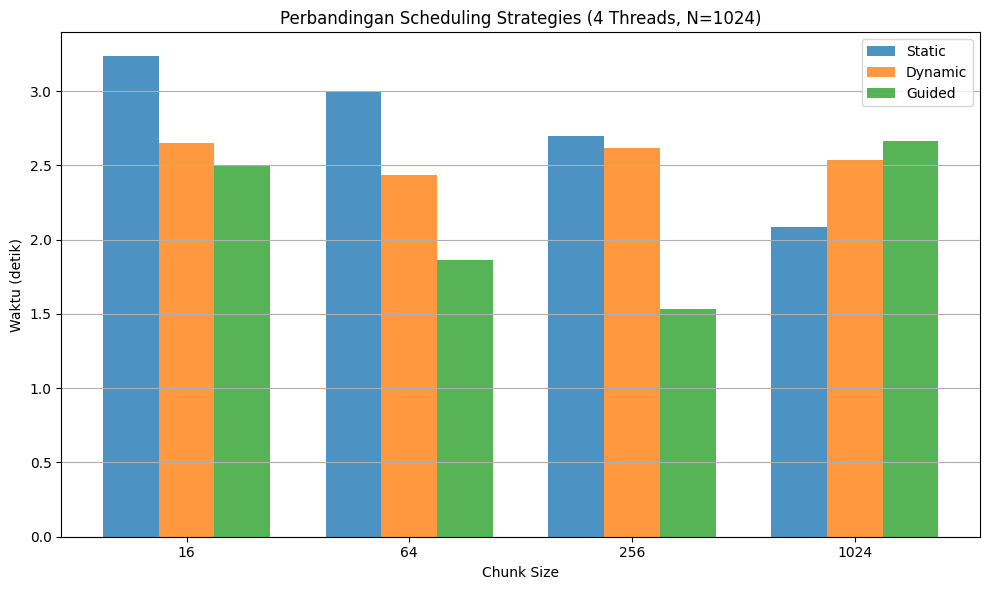

In [14]:
# Tabel dan visualisasi scheduling
for sched, times in sched_results.items():
    df = pd.DataFrame({'Chunk Size': chunk_sizes,
                       'Waktu (detik)': [f'{t:.4f}' for t in times],
                       'Speedup': [f'{serial_time/t:.3f}' for t in times]})
    print(f'\n--- {sched.upper()} Scheduling ---')
    print(df.to_string(index=False))

# Bar chart perbandingan
x = np.arange(len(chunk_sizes))
width = 0.25
fig, ax = plt.subplots(figsize=(10, 6))
for i, (sched, times) in enumerate(sched_results.items()):
    ax.bar(x + i*width, times, width, label=sched.capitalize(), alpha=0.8)
ax.set_xlabel('Chunk Size'); ax.set_ylabel('Waktu (detik)')
ax.set_title('Perbandingan Scheduling Strategies (4 Threads, N=1024)')
ax.set_xticks(x + width); ax.set_xticklabels(chunk_sizes)
ax.legend(); ax.grid(axis='y')
plt.tight_layout()
plt.savefig('openmp_files/scheduling_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


## Langkah 6: Investigasi False Sharing

In [15]:
%%writefile openmp_files/false_sharing.c
#include <stdio.h>
#include <stdlib.h>
#include <omp.h>

#define N 1000000
#define CACHE_LINE_SIZE 65
#define NUM_THREADS 16

// Teknik 1: Dengan False Sharing
double with_false_sharing() {
    int array[NUM_THREADS];
    double start = omp_get_wtime();
    #pragma omp parallel num_threads(NUM_THREADS)
    { int id = omp_get_thread_num();
      for (int i = 0; i < N; i++) array[id]++; }
    return omp_get_wtime() - start;
}

// Teknik 2: Padding untuk menghindari false sharing
typedef struct { int value; char pad[CACHE_LINE_SIZE - sizeof(int)]; } PaddedInt;
double with_padding() {
    PaddedInt array[NUM_THREADS];
    double start = omp_get_wtime();
    #pragma omp parallel num_threads(NUM_THREADS)
    { int id = omp_get_thread_num();
      for (int i = 0; i < N; i++) array[id].value++; }
    return omp_get_wtime() - start;
}

// Teknik 3: Private variable (reduction)
double with_private_var() {
    int results[NUM_THREADS];
    double start = omp_get_wtime();
    #pragma omp parallel num_threads(NUM_THREADS)
    { int local = 0; int id = omp_get_thread_num();
      for (int i = 0; i < N; i++) local++;
      results[id] = local; }
    return omp_get_wtime() - start;
}

int main() {
    double t1 = with_false_sharing();
    double t2 = with_padding();
    double t3 = with_private_var();
    printf("FS_TIME=%.4f\n", t1);
    printf("PAD_TIME=%.4f\n", t2);
    printf("PRIV_TIME=%.4f\n", t3);
    return 0;
}


Overwriting openmp_files/false_sharing.c


            Implementasi Waktu Rata-rata (detik) Improvement (%)
    Dengan False Sharing              0.00222000               -
    Padding (Mitigasi 1)              0.00052000          76.58%
Private Var (Mitigasi 2)              0.00076000          65.77%


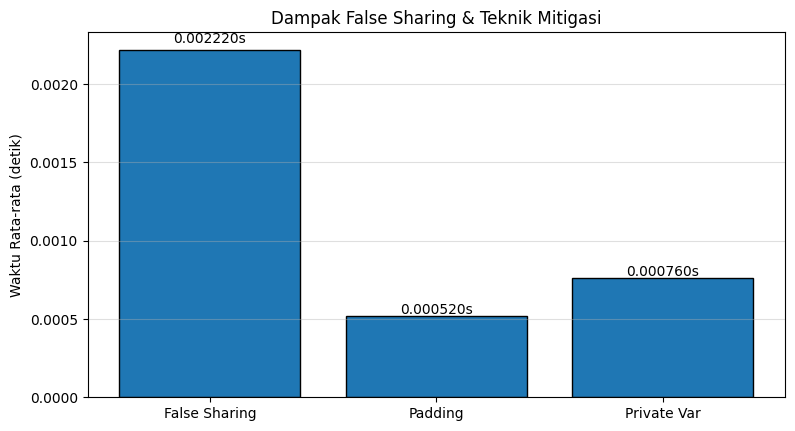

In [16]:
import subprocess
import pandas as pd
import matplotlib.pyplot as plt

# Compile
!gcc -fopenmp -O2 openmp_files/false_sharing.c -o openmp_files/false_sharing

# Jalankan benchmark beberapa kali
runs = 5
fs_times, pad_times, priv_times = [], [], []

for _ in range(runs):
    res = subprocess.run(
        './openmp_files/false_sharing',
        capture_output=True,
        text=True
    )

    out = res.stdout.splitlines()

    fs_times.append(float([l.split('=')[1] for l in out if 'FS_TIME' in l][0]))
    pad_times.append(float([l.split('=')[1] for l in out if 'PAD_TIME' in l][0]))
    priv_times.append(float([l.split('=')[1] for l in out if 'PRIV_TIME' in l][0]))

# Rata-rata
avg_fs   = sum(fs_times) / runs
avg_pad  = sum(pad_times) / runs
avg_priv = sum(priv_times) / runs

# Improvement
imp_pad  = (1 - avg_pad / avg_fs) * 100
imp_priv = (1 - avg_priv / avg_fs) * 100

# Tampilkan lebih presisi
df_fs = pd.DataFrame({
    'Implementasi': [
        'Dengan False Sharing',
        'Padding (Mitigasi 1)',
        'Private Var (Mitigasi 2)'
    ],
    'Waktu Rata-rata (detik)': [
        f'{avg_fs:.8f}',
        f'{avg_pad:.8f}',
        f'{avg_priv:.8f}'
    ],
    'Improvement (%)': [
        '-',
        f'{imp_pad:.2f}%',
        f'{imp_priv:.2f}%'
    ]
})

print(df_fs.to_string(index=False))

# Visualisasi
labels = ['False Sharing', 'Padding', 'Private Var']
avgs   = [avg_fs, avg_pad, avg_priv]

plt.figure(figsize=(9, 5))

bars = plt.bar(labels, avgs, edgecolor='black')

for bar, val in zip(bars, avgs):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() * 1.02,
        f'{val:.6f}s',
        ha='center',
        fontsize=10
    )

plt.ylabel('Waktu Rata-rata (detik)')
plt.title('Dampak False Sharing & Teknik Mitigasi')

plt.grid(axis='y', alpha=0.4)

# Hindari warning tight_layout
plt.subplots_adjust(top=0.88, bottom=0.15)

plt.savefig(
    'openmp_files/false_sharing_analysis.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()


## Langkah 7: Eksperimen Tambahan – Variasi Ukuran Matriks

In [17]:
%%writefile openmp_files/matrix_sizes.c
#include <stdio.h>
#include <stdlib.h>
#include <omp.h>

int main(int argc, char* argv[]) {
    int N = (argc > 1) ? atoi(argv[1]) : 512;
    int T = (argc > 2) ? atoi(argv[2]) : 4;
    omp_set_num_threads(T);
    double *A = malloc(N*N*sizeof(double));
    double *B = malloc(N*N*sizeof(double));
    double *C = malloc(N*N*sizeof(double));
    if (!A || !B || !C) { printf("Alokasi gagal\n"); return 1; }
    srand(42);
    for (int i = 0; i < N*N; i++) {
        A[i] = (double)rand()/RAND_MAX;
        B[i] = (double)rand()/RAND_MAX; }
    double start = omp_get_wtime();
    #pragma omp parallel for
    for (int i = 0; i < N; i++)
        for (int j = 0; j < N; j++) {
            double sum = 0;
            for (int k = 0; k < N; k++)
                sum += A[i*N+k] * B[k*N+j];
            C[i*N+j] = sum;
        }
    printf("N=%d T=%d TIME=%.4f\n", N, T, omp_get_wtime()-start);
    free(A); free(B); free(C);
    return 0;
}


Overwriting openmp_files/matrix_sizes.c


In [18]:
!gcc -fopenmp -O2 openmp_files/matrix_sizes.c -o openmp_files/matrix_sizes

matrix_sizes = [256, 512, 1024, 2048]
thread_test  = [1, 2, 4, 8]
size_results = {n: [] for n in matrix_sizes}

for n in matrix_sizes:
    print(f'--- N={n} ---')
    for t in thread_test:
        res = subprocess.run(f'./openmp_files/matrix_sizes {n} {t}',
                             shell=True, capture_output=True, text=True)
        line = res.stdout.strip()
        if 'TIME=' in line:
            time_val = float(line.split('TIME=')[1])
            size_results[n].append(time_val)
            print(f'  Threads={t}: {time_val:.4f}s')
        else:
            size_results[n].append(None)
            print(f'  Threads={t}: ERROR')

print('\nEksperimen ukuran matriks selesai!')


--- N=256 ---
  Threads=1: 0.0215s
  Threads=2: 0.0134s
  Threads=4: 0.0077s
  Threads=8: 0.0179s
--- N=512 ---
  Threads=1: 0.3783s
  Threads=2: 0.1934s
  Threads=4: 0.0908s
  Threads=8: 0.0887s
--- N=1024 ---
  Threads=1: 10.3354s
  Threads=2: 4.5501s
  Threads=4: 2.6528s
  Threads=8: 1.7339s
--- N=2048 ---
  Threads=1: 114.4314s
  Threads=2: 82.0534s
  Threads=4: 57.7976s
  Threads=8: 46.1901s

Eksperimen ukuran matriks selesai!


In [19]:
for i in range(5):
    res = subprocess.run(
        './openmp_files/false_sharing',
        capture_output=True,
        text=True
    )

    out = res.stdout.splitlines()

    fs = float([l.split('=')[1] for l in out if 'FS_TIME' in l][0])
    pad = float([l.split('=')[1] for l in out if 'PAD_TIME' in l][0])
    priv = float([l.split('=')[1] for l in out if 'PRIV_TIME' in l][0])

    print(f'Run {i+1}: FS={fs:.8f}  PAD={pad:.8f}  PRIV={priv:.8f}')

Run 1: FS=0.00310000  PAD=0.00060000  PRIV=0.00050000
Run 2: FS=0.00170000  PAD=0.00050000  PRIV=0.00050000
Run 3: FS=0.00180000  PAD=0.00060000  PRIV=0.00050000
Run 4: FS=0.00170000  PAD=0.00060000  PRIV=0.00050000
Run 5: FS=0.00230000  PAD=0.00060000  PRIV=0.00070000


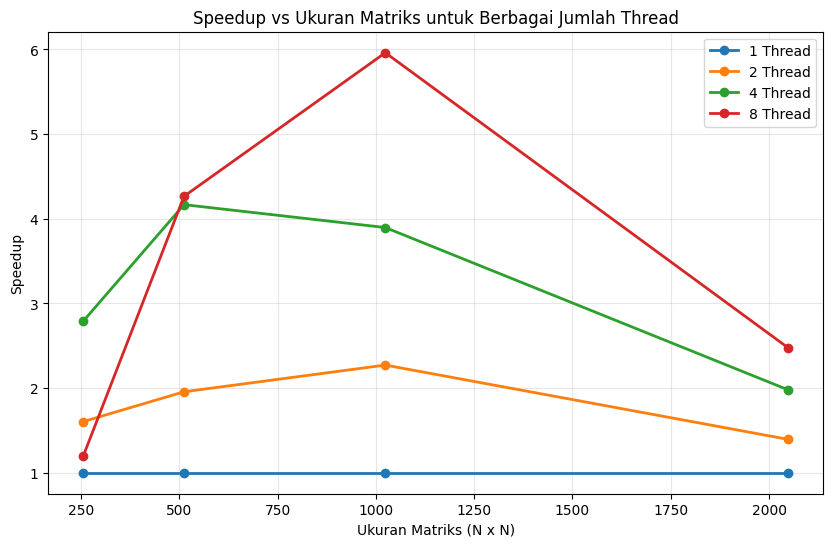

Grafik disimpan ke openmp_files/scalability_speedup.png


In [20]:
# Grafik 4: Speedup vs Ukuran Matriks untuk berbagai jumlah thread

import matplotlib.pyplot as plt
import pandas as pd

# Data hasil eksperimen
sizes = [256, 512, 1024, 2048]

serial_times = {
    256: 0.0215,
    512: 0.3783,
    1024: 10.3354,
    2048: 114.4314
}

parallel_times = {
    1: [0.0215, 0.3783, 10.3354, 114.4314],
    2: [0.0134, 0.1934, 4.5501, 82.0534],
    4: [0.0077, 0.0908, 2.6528, 57.7976],
    8: [0.0179, 0.0887, 1.7339, 46.1901]
}

# Hitung speedup
speedup_data = {}

for threads, times in parallel_times.items():
    speedups = []
    for n, t in zip(sizes, times):
        speedups.append(serial_times[n] / t)
    speedup_data[threads] = speedups

# Plot
plt.figure(figsize=(10,6))

for threads, speedups in speedup_data.items():
    plt.plot(
        sizes,
        speedups,
        marker='o',
        linewidth=2,
        label=f'{threads} Thread'
    )

plt.xlabel('Ukuran Matriks (N x N)')
plt.ylabel('Speedup')
plt.title('Speedup vs Ukuran Matriks untuk Berbagai Jumlah Thread')
plt.grid(True, alpha=0.3)
plt.legend()

plt.savefig(
    'openmp_files/scalability_speedup.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print("Grafik disimpan ke openmp_files/scalability_speedup.png")